In [1]:
import os
# Switch to parent directory
os.chdir("..")
root = os.getcwd()

In [2]:
import sys
sys.path.insert(0, os.path.join(root, "src"))

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from spo.optim import min_var_portfolio, max_sharpe_portfolio, efficient_frontier
from spo.backtest import backtest, summary
from spo.risk import hist_var, hist_cvar

simple_ret = pd.read_parquet(root + "/data/processed/sp500_simple_returns.parquet")
print(f"Shape: {simple_ret.shape}")
print(f"Range: {simple_ret.index.min().date()} - {simple_ret.index.max().date()}")
simple_ret.head()

Shape: (4017, 429)
Range: 2010-08-09 - 2025-12-30


,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
2010-08-09,0.037939,0.006382,0.006130,0.010831,0.007450,0.009921,0.010606,0.014911,0.004811,0.009037,...,0.028561,0.013897,0.009061,0.013978,0.024475,0.006781,0.007746,0.007791,0.000185,0.006614
2010-08-10,-0.012073,-0.008940,0.011596,-0.001134,-0.002465,-0.011856,-0.019678,0.000326,-0.009816,-0.014812,...,-0.021442,-0.019580,-0.012508,-0.009764,-0.022136,0.006287,-0.008327,-0.007027,-0.001668,-0.015440
2010-08-11,-0.042091,-0.035542,-0.020983,-0.022463,-0.011860,-0.031539,-0.026765,-0.026110,-0.023210,-0.023776,...,-0.041666,-0.025392,-0.019162,-0.051044,-0.046479,-0.011602,-0.017889,-0.029252,-0.035065,-0.030364
2010-08-12,-0.024451,0.006395,0.000000,0.000387,-0.013253,-0.006018,-0.029564,0.025470,-0.009902,-0.016834,...,0.008621,0.010831,-0.008278,0.006112,-0.002982,0.005870,-0.002650,-0.003645,-0.000192,-0.010323
2010-08-13,-0.006539,-0.010683,-0.006549,-0.005420,-0.015459,-0.002493,-0.005668,-0.017974,-0.005250,0.024408,...,-0.008547,-0.028092,-0.001002,-0.006075,0.003796,0.006284,-0.005313,-0.003659,-0.010769,-0.011474


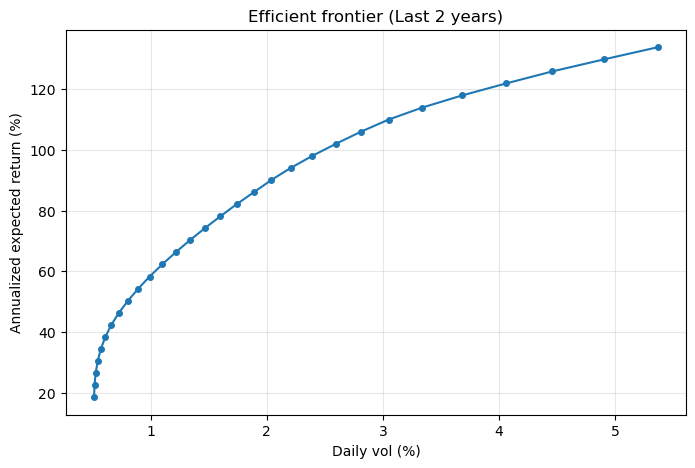

In [4]:
frontier = efficient_frontier(simple_ret.iloc[-504:], n_points=30)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(frontier["vol"] * 100, frontier["expected_return"] * 252 * 100, "-o", ms=4)
ax.set_xlabel("Daily vol (%)")
ax.set_ylabel("Annualized expected return (%)")
ax.set_title("Efficient frontier (Last 2 years)")
ax.grid(alpha=0.3)
plt.show()

In [5]:
def equal_weight(r):
    return pd.Series(1.0 / r.shape[1], index=r.columns)

strategies = {
    "Equal-Weight": equal_weight,
    "Min-Variance": lambda r: min_var_portfolio(r, covariance="ledoit_wolf"),
    "Max-Sharpe": lambda r: max_sharpe_portfolio(r, covariance="ledoit_wolf"),
}

results = {
    name: backtest(simple_ret, fn, rebalance_freq="BME",
                                lookback=504, cost=10.0)
    for name, fn in strategies.items()
}

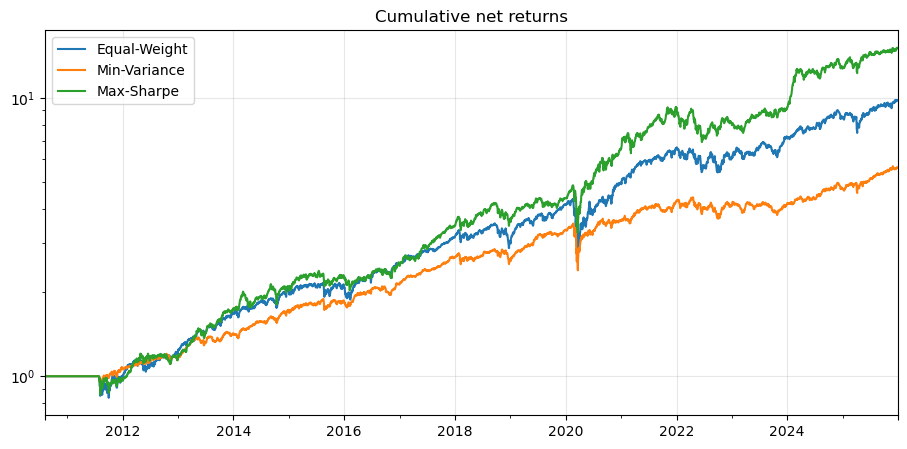

,Equal-Weight,Min-Variance,Max-Sharpe
Ann. Returns,0.153761,0.114296,0.185434
Ann. Vol,0.169048,0.118598,0.173199
Sharpe,0.931150,0.972269,1.069334
Sortino,1.085551,1.100459,1.292837
Max DD,-0.375121,-0.320706,-0.323462
Calmar,0.409898,0.356390,0.573277


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    (1 + res["net_returns"]).cumprod().plot(ax=ax, label=name)
ax.set_yscale("log")
ax.set_title("Cumulative net returns")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

pd.concat({name: summary(res["net_returns"]) for name, res in results.items()}, axis=1)

In [7]:
for name, res in results.items():
    r = res["net_returns"].dropna()
    print(f"{name}: 5% VaR = {hist_var(r, 0.05):.4%}   "
          f"5% CVaR = {hist_cvar(r, 0.05):.4%}")

Equal-Weight: 5% VaR = -1.5270%   5% CVaR = -2.5501%
Min-Variance: 5% VaR = -1.0028%   5% CVaR = -1.6984%
Max-Sharpe: 5% VaR = -1.6184%   5% CVaR = -2.5981%
